# Dynamic Delta Hedging of a European Call Option

This project simulates stock price dynamics using a Geometric Brownian Motion (GBM) and studies the effectiveness of a dynamic delta hedging strategy on a European call option.

The objective is to measure how periodic delta rebalancing reduces the risk of an option position and to analyse the behaviour of the main Black-Scholes Greeks (Delta, Gamma and Vega) through time.

The project is implemented entirely in Python using NumPy, Pandas, Matplotlib and the Black-Scholes framework.



In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
np.random.seed(1)

# Model Assumptions

## Stock Dynamics

The underlying stock price follows a Geometric Brownian Motion (GBM):

* Constant volatility
* Constant risk-free rate
* Log-normal stock returns
* No dividends

## Option Pricing

The option is priced using the Black-Scholes model:

* Pack of 100 European Call Option
* Spot = $100
* Strike = $100
* Notional = $ 1 millions (10 000 shares of stock)
* Maturity = 1 year
* Volatility = 20%
* Risk-free rate = 2%

## Simulation Setup

* 10 simulated price paths
* 21 trading days observed
* Daily rebalancing of the hedge
* Delta recalculated every day
* Hedging performed using the underlying stock only


In [25]:
S0 = 100
sigma = 0.20
r = 0.02

K = 100
T = 1
n_contracts = 100 #pack of 100 options
notional = n_contracts * 100 # 10 000 shares 
#$100 * 10 000 shares = 1 millions $

n_days = 21
dt = 1/252
n_paths = 10



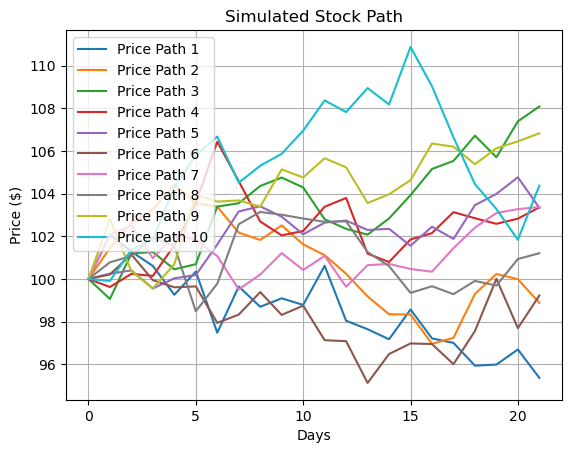

In [26]:
# Creation of a matrix filled with 0 to store simulated stock paths
# rows = number of simulated paths
# columns = number of observed days + 1 to include day 0
paths = np.zeros((n_paths, n_days + 1))

for i in range(n_paths):  # loop over each simulated path

    # calculation of GBM log-returns
    returns = (r - sigma**2 / 2) * dt + sigma / np.sqrt(252) * np.random.randn(n_days)

    # insert 0 at the beginning because the return at day 0 is 0
    # returns start evolving from day 1
    returns = np.insert(returns, 0, 0)

    # calculation of stock prices from cumulative log-returns
    S = S0 * np.exp(np.cumsum(returns))
    
    # store the full trajectory in the matrix
    # i= current path, : = all days
    paths[i, :] = S

    #plot curve for each simulated stock path
    #x-axis = days, y-axis = stock price
    plt.plot(range(n_days + 1), paths[i, :], label=f'Price Path {i+1}')

plt.title('Simulated Stock Path')#chart title
plt.xlabel('Days')#x lavel
plt.ylabel('Price ($)')# y label
plt.grid(True)#greed on the chart
plt.legend()#legend for each trajectory
plt.show()



In [27]:
option_paths = np.zeros((n_paths, n_days + 1))
delta_options = np.zeros((n_paths, n_days + 1))
gamma_options = np.zeros((n_paths, n_days + 1))
vega_options = np.zeros((n_paths, n_days + 1))

In [28]:
def bs_greeks(S, K, r, sigma, T_t):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T_t) / (sigma * np.sqrt(T_t))
    d2 = d1 - sigma * np.sqrt(T_t)
    return {
        "BS_price": S * norm.cdf(d1) - K * np.exp(-r * T_t) * norm.cdf(d2),
        "delta":    norm.cdf(d1),
        "gamma":    norm.pdf(d1) / (S * sigma * np.sqrt(T_t)),
        "vega":     (S * norm.pdf(d1) * np.sqrt(T_t)) / 100
    }


In [29]:
for path in range(n_paths):
    for t in range(n_days + 1):
        S_path = paths[path, t]
        T_t = T - t * dt
        g = bs_greeks(S_path, K, r, sigma, T_t)

        option_paths[path, t]  = g["BS_price"]
        delta_options[path, t] = g["delta"]
        gamma_options[path, t] = g["gamma"]
        vega_options[path, t]  = g["vega"]
print(
    f'The premium of one option today is ${option_paths[0,0]:.2f}, '
    f'which means the total premium received is '
    f'${option_paths[0,0] * S0 * n_contracts:,.1f}')

The premium of one option today is $8.92, which means the total premium received is $89,160.4


In [30]:
# Delta-hedging position in underlying shares
stock_position_delta = np.zeros((n_paths, n_days + 1))
for path in range(n_paths):
    for t in range(n_days + 1):
    
        # Convert option delta into number of shares held
        stock_position_delta[path, t] = delta_options[path, t] * notional
print(
    f'If the spot price increases by $1 today, the portfolio value would '
    f'decrease by approximately ${stock_position_delta[0,0]:,.0f} '
    f'on the short option position, offset by the delta hedge.'
)

If the spot price increases by $1 today, the portfolio value would decrease by approximately $5,793 on the short option position, offset by the delta hedge.


In [31]:
# Scaled gamma (portfolio view)
gamma_exposure = np.zeros((n_paths, n_days + 1))

for path in range(n_paths):
    for t in range(n_days + 1):
        # Gamma scaled to portfolio size
        gamma_exposure[path, t] = gamma_options[path, t] * notional
print(
    f'If the spot price increases by $1 today, the portfolio delta would '
    f'increase by approximately {gamma_exposure[0,0]:,.0f} shares, '
    f'meaning we would need to buy additional shares '
    f'to remain delta-neutral.')

If the spot price increases by $1 today, the portfolio delta would increase by approximately 196 shares, meaning we would need to buy additional shares to remain delta-neutral.


In [32]:
# Portfolio vega exposure
vega_exposure = np.zeros((n_paths, n_days + 1))

for path in range(n_paths):
    for t in range(n_days + 1):
        # Vega scaled to portfolio size
        vega_exposure[path, t] = vega_options[path, t] * notional
print(
    f'If the implied volatility increases by 1% today, '
    f'the option portfolio value would decrease by '
    f'approximately ${vega_exposure[0,0]:,.0f}.')

If the implied volatility increases by 1% today, the option portfolio value would decrease by approximately $3,910.


In [33]:
# Create MultiIndex columns: days with sub-columns (delta, gamma, vega)
days = range(n_days + 1) 
metrics = ['delta', 'gamma', 'vega']
columns = pd.MultiIndex.from_product([days, metrics], names=['Day', 'Metric'])

# Create the data array with proper shape
# Shape should be (n_paths, (n_days + 1) * 3) where 3 is for delta, gamma, vega
data = []

for path in range(n_paths):  # paths 0 to 9 (assuming n_paths = 10)
    row_data = []
    for t in range(n_days + 1):  
        # Add delta, gamma, vega for each day in order
        row_data.extend([
             stock_position_delta[path, t],
            gamma_exposure[path, t],
            vega_exposure[path, t]])
    data.append(row_data)#append add our greeks to the list row_data

# Create DataFrame with MultiIndex columns and path numbers as index
df_greeks = pd.DataFrame(data, 
                        columns=columns, 
                        index=pd.Index(range(n_paths), name='Path'))
df_greeks = df_greeks.round(1)
df_greeks

Day         0                      1                      2                  \
Metric   delta  gamma    vega   delta  gamma    vega   delta  gamma    vega   
Path                                                                          
0       5792.6  195.5  3910.4  6187.2  187.1  3882.5  6038.2  191.0  3887.5   
1       5792.6  195.5  3910.4  6071.3  189.9  3892.8  6287.8  184.9  3863.0   
2       5792.6  195.5  3910.4  5605.8  199.4  3898.6  6021.8  191.4  3888.5   
3       5792.6  195.5  3910.4  5717.3  197.4  3902.3  5836.5  195.4  3895.2   
4       5792.6  195.5  3910.4  5839.9  194.9  3902.7  5867.8  194.7  3894.7   
5       5792.6  195.5  3910.4  5832.8  195.1  3902.7  6013.2  191.6  3889.1   
6       5792.6  195.5  3910.4  6188.0  187.1  3882.4  6268.5  185.4  3865.5   
7       5792.6  195.5  3910.4  5943.1  192.7  3900.0  5998.7  191.9  3889.9   
8       5792.6  195.5  3910.4  6322.7  183.6  3865.8  5862.2  194.8  3894.8   
9       5792.6  195.5  3910.4  5773.0  196.3  3902.9  6056.4  190.6  3886.3   

Day         3   ...      18      19                     20                 \
Metric   delta  ...    vega   delta  gamma    vega   delta  gamma    vega   
Path            ...                                                         
0       5907.6  ...  3687.2  4917.8  216.1  3681.4  5067.0  215.0  3700.8   
1       6407.0  ...  3771.1  5809.7  202.7  3765.5  5758.9  204.1  3758.0   
2       6033.1  ...  3564.7  6847.7  174.8  3612.0  7134.7  165.2  3507.2   
3       5816.4  ...  3733.8  6274.6  191.8  3732.7  6320.3  191.0  3718.5   
4       5700.2  ...  3715.2  6538.5  184.5  3688.7  6681.2  180.5  3648.8   
5       5777.1  ...  3742.7  5764.2  203.6  3765.8  5280.4  212.3  3730.3   
6       5976.9  ...  3744.9  6371.4  189.2  3718.8  6405.0  188.7  3705.4   
7       6163.8  ...  3773.5  5699.3  204.9  3765.3  5950.3  200.1  3753.6   
8       5700.3  ...  3636.6  6920.6  172.3  3589.8  6976.9  170.8  3563.7   
9       6145.2  ...  3678.6  6406.8  188.2  3713.0  6128.5  195.9  3741.1   

Day         21                 
Metric   delta  gamma    vega  
Path                           
0       4775.0  218.1  3636.7  
1       5527.3  208.9  3743.7  
2       7249.7  161.2  3453.2  
3       6421.2  188.6  3694.7  
4       6416.2  188.8  3695.6  
5       5600.1  207.6  3747.1  
6       6424.0  188.6  3694.2  
7       6003.5  199.3  3742.8  
8       7042.0  168.9  3533.5  
9       6610.2  183.1  3657.5  

[10 rows x 66 columns]

In [34]:
delta_position_variation = np.diff(stock_position_delta, axis=1)#np.diff calculate the variation between t-1 and t
df_delta_hedging = pd.DataFrame(delta_position_variation.T).round(1)
df_delta_hedging

,0,1,2,3,4,5,6,7,8,9
0,394.6,278.7,-186.8,-75.3,47.3,40.2,395.4,150.5,530.1,-19.6
1,-149.0,216.5,416.0,119.2,27.9,180.3,80.5,55.7,-460.6,283.4
2,-130.6,119.2,11.3,-20.2,-167.7,-236.1,-291.6,165.1,-161.8,88.8
3,-268.0,211.3,-157.8,276.9,92.2,-67.9,209.4,-76.2,221.9,452.6
4,213.9,-160.3,45.9,364.8,28.7,6.4,-44.7,-606.4,609.2,255.3
5,-580.5,-29.4,509.1,503.3,277.4,-347.6,-148.9,258.9,-58.7,148.3
6,438.5,-225.6,28.4,-317.9,289.6,77.5,-307.6,537.4,10.2,-369.8
7,-193.8,-66.1,145.7,-343.0,44.0,211.7,136.3,105.9,-54.0,139.8
8,78.7,128.7,70.4,-123.3,-90.4,-219.7,196.0,-24.4,313.1,96.7
9,-65.3,-170.1,-82.3,38.5,-155.9,86.9,-156.5,-33.3,-66.4,183.0


In [35]:
# 1) Variations between t-1 and t
dS = paths[:, 1:] - paths[:, :-1]  #dS = Spot price change between 2 days
dC = option_paths[:, 1:] - option_paths[:, :-1] #dC = Call price change between 2 days 

# 2) Portfolio delta at t-1 
delta_prev = delta_options[:, :-1] * notional #Portfolio delta in shares at t-1 

# 3) Portfolio values à t-1
C_prev = option_paths[:, :-1] * notional #Potfolio option value in $ at t-1
stock_prev = delta_prev * paths[:, :-1] #Value of the stock (hedge) position in $ at t-1

# 4) Financing term
funding = r * (stock_prev - C_prev) * dt # r = rate, dt = time step

# 5) Daily PnL of a short call seller with delta hedge
pnl_daily = - dC * notional + delta_prev * dS - funding

# 6) PnL cumulated per path
pnl_total = pnl_daily.sum(axis=1)

# 7) DataFrame  : rows = days, columns = paths
df_pnl_daily = pd.DataFrame(pnl_daily.T, columns=[f'Path {i}' for i in range(n_paths)])
df_pnl_daily = df_pnl_daily.round(1)
df_pnl_daily

,Path 0,Path 1,Path 2,Path 3,Path 4,Path 5,Path 6,Path 7,Path 8,Path 9
0,-254.2,-47.1,67.4,141.0,149.6,151.2,-255.9,96.9,-592.3,154.4
1,96.3,29.8,-289.7,119.4,153.7,71.3,137.4,147.5,-399.9,-52.7
2,111.6,115.9,155.4,154.9,84.7,13.1,-68.4,84.0,89.6,134.8
3,-24.8,29.2,91.9,-42.7,134.8,144.7,40.6,140.3,30.6,-409.3
4,40.7,81.5,151.2,-204.2,154.5,156.5,150.5,-765.9,-847.7,-36.1
5,-670.6,152.2,-536.4,-583.6,-42.2,-140.2,98.7,-10.7,144.5,84.7
6,-319.0,19.0,152.9,-141.7,-68.0,141.8,-81.6,-597.3,154.5,-245.6
7,64.9,145.2,96.1,-166.7,150.4,46.4,110.9,126.1,147.0,97.8
8,142.4,113.5,140.3,116.4,133.7,39.7,59.8,154.4,-120.3,125.4
9,147.7,81.4,135.0,153.6,92.4,139.3,95.8,153.5,140.7,51.3


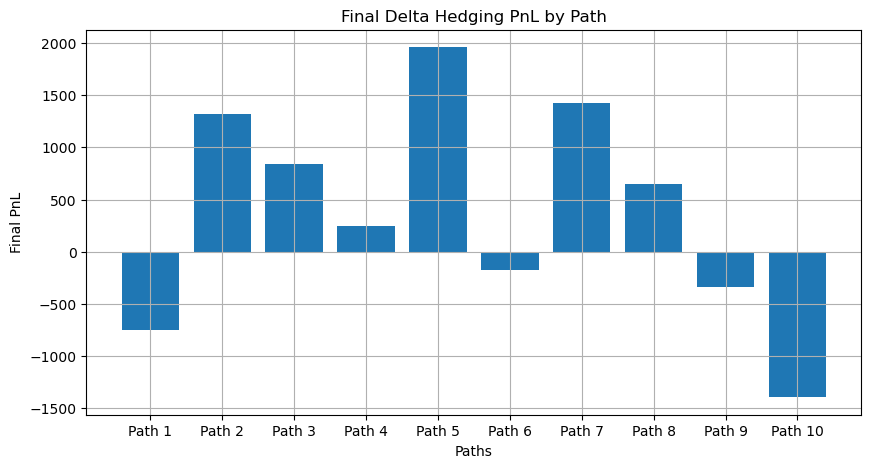

In [36]:
# PnL total final de chaque trajectoire

# Plot
plt.figure(figsize=(10,5))

plt.bar([f'Path {i+1}' for i in range(n_paths)], pnl_total)

plt.title("Final Delta Hedging PnL by Path")
plt.xlabel("Paths")
plt.ylabel("Final PnL")
plt.grid(True)

plt.show()

In [37]:
pnl_total = pnl_daily.sum(axis=1)

df_pnl_total = pd.DataFrame(pnl_total, columns=["Final PnL in $"])

df_pnl_total.index = [f'Path {i+1}' for i in range(n_paths)]

df_pnl_total = df_pnl_total.round(1)
df_pnl_total

,Final PnL in $
Path 1,-746.0
Path 2,1318.3
Path 3,841.8
Path 4,248.5
Path 5,1959.6
Path 6,-171.2
Path 7,1426.9
Path 8,651.8
Path 9,-336.1
Path 10,-1393.8


In [38]:
# Hedging effectiveness DataFrame
unhedged_pnl = dC.sum(axis=1) * notional # PnL without hedge
hedged_pnl   = pnl_total                 # PnL with hedge

#DataFrame settled to show the hedge effectivness
df_effectiveness = pd.DataFrame({
    'Unhedged PnL ($)': unhedged_pnl,
    'Hedged PnL ($)'  : hedged_pnl,
}, index=[f'Path {i+1}' for i in range(n_paths)])

df_effectiveness.loc['Max losses'] = df_effectiveness.min()#Add maximal loss at the end of the DataFrame with loc function
df_effectiveness = df_effectiveness.round(1)
print(df_effectiveness)

# Extract max loss values
max_loss_unhedged = df_effectiveness.loc['Max losses', 'Unhedged PnL ($)']
max_loss_hedged   = df_effectiveness.loc['Max losses', 'Hedged PnL ($)']
risk_reduction    = (1 - abs(max_loss_hedged) / abs(max_loss_unhedged)) * 100 #abs function remove sign - from number, to calculte difference in %

print(f'\nThe maximum loss for the worst price path in our Monte Carlo simulation shows that:')
print(f'  - Without hedge : ${max_loss_unhedged:,.1f}')
print(f'  - With dynamic delta hedge : ${max_loss_hedged:,.1f}')
print(f'  - Risk reduction : {risk_reduction:.1f}%')
print(f'\nDynamic delta hedging reduces the worst-case loss by {risk_reduction:.1f}%, '
      f'from ${abs(max_loss_unhedged):,.1f} to ${abs(max_loss_hedged):,.1f} '
      f'over a 1-month horizon.')

            Unhedged PnL ($)  Hedged PnL ($)
Path 1              -28593.9          -746.0
Path 2              -10481.2          1318.3
Path 3               48700.5           841.8
Path 4               16334.2           248.5
Path 5               16166.1          1959.6
Path 6               -8536.0          -171.2
Path 7               16430.0          1426.9
Path 8                2960.8           651.8
Path 9               39707.0          -336.1
Path 10              22959.3         -1393.8
Max losses          -28593.9         -1393.8

The maximum loss for the worst price path in our Monte Carlo simulation shows that:
  - Without hedge : $-28,593.9
  - With dynamic delta hedge : $-1,393.8
  - Risk reduction : 95.1%

Dynamic delta hedging reduces the worst-case loss by 95.1%, from $28,593.9 to $1,393.8 over a 1-month horizon.


# Interpretation of Results

The results show that dynamic delta hedging significantly reduces the directional exposure of the option position.

As the stock price evolves, the hedge ratio is updated daily, generating stock purchases and sales that offset most of the option's sensitivity to price movements.

Residual profit and loss remain because:
* Hedging is discrete rather than continuous
* Gamma exposure is not hedged
* The stock path differs from the assumptions of perfect replication

Overall, the remaining PnL is substantially smaller than the unhedged option exposure, demonstrating the effectiveness of delta hedging as a risk management tool.
